# Datos y funciones de interpolación

Se dice que una función interpola a un conjunto de puntos si pasa a través de esos puntos. La función $y = P(x)$ interpola los puntos $(x_1,y_1),...,(x_n, y_n)$ si $P(x_i) = y_i$ para cada $1 \le i \le n$. Tener en cuenta que es necesario que $P$ sea una función.

# Interpolación de Lagrange

Suponga que se tiene n puntos de datos y que se desea encontrar un polinomio de interpolación. Existe una fórmula explícita, llamada fórmula de interpolación de Lagrange, para escribir un polinomio de grado $d = n - 1$ que interpola los puntos. Suponga que se tienen tres puntos. Entonces, el polinomio:

$$P_2(x)=y_1\frac{(x-x_2)(x-x_3)}{(x_1 - x_2)(x_1 - x_3)}+y_2\frac{(x - x_1)(x-x_3)}{(x_2 - x_1)(x_2 - x_3)} + y_3\frac{(x - x_1)(x - x_2)}{(x_3 - x_1)(x_3 - x_2)}$$

es el polinomio de interpolación de Lagrange que pasa por estos puntos.

Ejemplo: Encuentre el polinomio de interpolación de Lagrange para los puntos $(0,1), (2,2), (3,4)$.

$$P_2(x) = 1\frac{(x-2)(x-3)}{(0-2)(0-4)}+2\frac{(x-0)(x-3)}{(2-0)(2-3)} + 4\frac{(x - 0)(x-2)}{(3-0)(3-2)}$$

$$P_2(x)=\frac{1}{2}x^2 - \frac{1}{2}x + 1$$

En general, suponga que se tienen n puntos. Para cada k entre 1 y n, se define el polinomio de grado n-1:

$$L_k(x) = \frac{(x-x_1)...(x-x_{k-1})(x-x_{k+1})...(x-x_n)}{(x_k - x_1)...(x_k-x_{k-1})(x_k - x_{k+1})...(x_k - x_n)}$$

Donde $L_k(x_k) = 1$, mientras que $L_k(x_j) = 0$, donde $x_j$ es cualquiera de los otros puntos.

Entonces, se define el polinomio como:

$$P_{n-1}(x) = y_1L_1(x) + y_2L_2(x) + ... + y_nL_n(x)$$

O en una notación más compacta:

$$L_j(x) = \prod_{i=1, i \neq j}^n \frac{(x - x_i)}{(x_j - x_i)}$$

$$P_{n-1}(x) = \sum_{j = 1}^n y_jL_j(x)$$

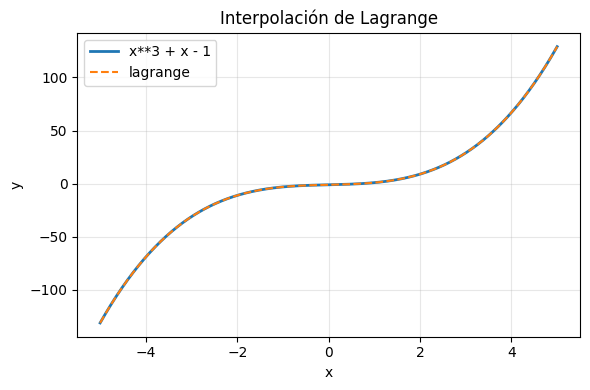

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def lagrange(x, px, py):

    n = px.shape[0]
    
    P = np.zeros(x.shape[0])

    for j in range(n):

        L = np.ones((x.shape[0]))

        for i in range(n):

            if i != j:
                L *= (x - px[i])/(px[j] - px[i])

            
        P += py[j]*L

    return P

def f(x):
    return x**3 + x - 1

px = np.array([-1, 0, 1, 2])
py = np.array([ -3,-1, 1, 9])

valores = np.linspace(-5,5,1000)
p = lagrange(valores, px, py)

fig, ax = plt.subplots(figsize = (6,4))
ax.plot(valores, f(valores), lw = 2, label = 'x**3 + x - 1')
ax.plot(valores, p, ls = '--' ,label = 'lagrange')
ax.set_title('Interpolación de Lagrange')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()
    
    

# Diferencias divididas de Newton

Suponga que las parejas de puntos provienen de una función $f(x)$ por lo que el objetivo es interpolar $(x_i, f(x_1)),...,(x_n, f(x_n))$.

Indique mediante $f[x_1 ... x_n]$ el cociente del término $x^{n-1}$ en el polinomio (único) que interpola  $(x_i, f(x_1)),...,(x_n, f(x_n))$.

Por ejemplo para los puntos $(0,1),(2,2), (3,4)$ un polinomio interpolador es:
$$P_2(x)=\frac{1}{2}x^2 - \frac{1}{2}x + 1$$

Entonces $f[0\,\,2\,\,3] = \frac{1}{2}$. Note que permutar los valores en los corchetes da el mismo resultado. Las diferencias divididas de $f$ respecto a $x_0,...x,_n$ se usan para expresar $P_n(x)$ de la forma:

$$P_n(x) = a_0 + a_1(x-x_0) + a_2(x-x_0)(x-x_1) + ... + a_n(x-x_0)...(x-x_{n-1})$$

Note que si $x = x_0$ entonces $P_n(x_0) = a_0 = f(x_0)$, luego si $x = x_1$ entonces:

$$P_n(x_1) = f(x_1) = f(x_0) + a_1(x-x_0)$$
$$a_1 = \frac{f(x_1) - f(x_0)}{x_1-x_0}$$

La ceroésima diferencia dividida de la función $f$ respecto a $x_i$, denotada $f[x_i]$ es simplemente el valor de $f$ en $x_i$:

$$f[x_i] = f(x_i)$$

Las diferencias divididas restantes se definen de manera recursiva, la primera diferencia dividida de $f$ respecto a $x_i$ y $x_{i+1}$ se denota $f[x_i, x_{i+1}]$ y se define como:

$$f[x_i, x_{i+1}] = \frac{f[x_{i+1}]-f[x_{i}]}{x_{i+1} - x_i}$$

La segunda como:

$$f[x_i, x_{i+1}, x_{i+2}] = \frac{f[x_{i+1}, x_{i+2}]-f[x_{i}, x_{i+1}]}{x_{i+2} - x_i}$$

Luego de las $(k-1)$-ésimas diferencias divididas, se determina la k-ésima diferencia divida relativa entre $x_i,...,x_{i+k}$:

$$f[x_i, x_{i+1},..., x_{i+k-1}, x_{i+k}] = \frac{f[x_{i+1},.., x_{i+k}]-f[x_{i},..., x_{i+k-1}]}{x_{i+k} - x_i}$$

El proceso termina con la única enésima diferencia dividida:

$$f[x_0, x_1, ..., x_n] = \frac{f[x_1, x_2, ..., x_n] - f[x_0,x_1,...x_{n-1}]}{x_n - x_0}$$

El polinomio de interpolación es:

$$P_n(x) = f[x_0] + f[x_0,x_1](x-x_0) + ... + f[x_0,...,x_n](x-x_0)(x-x_1)...,(x-x_{n-1})$$

$$P_n(x) = f[x_0] + \sum_{k=1}^n f[x_0,x_1,...,x_k](x-x_0)...(x-x_{k-1})$$

<center>

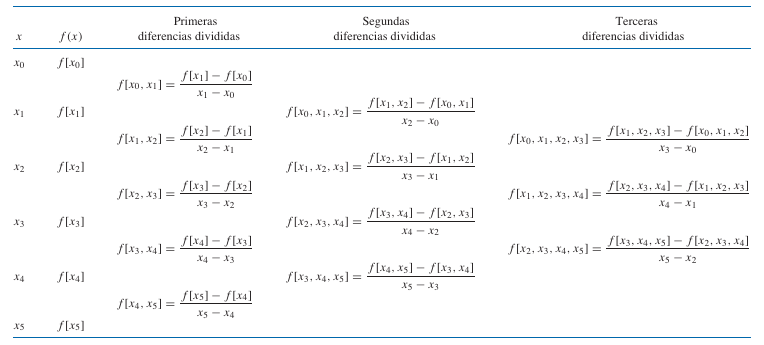

<center>

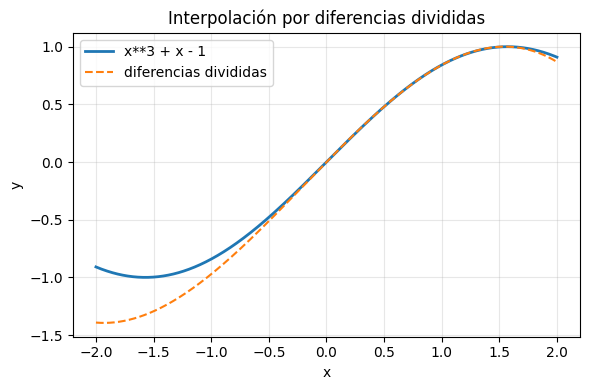

In [2]:
# Diferencias divididas

def diferencias_divididas(x, px, py):
    n = px.shape[0]

    Q = np.zeros((n, n), dtype=float)
    Q[:,0] = py 

    for j in range(1, n):

        for i in range(j,n):

            Q[i,j] = (Q[i,j-1] - Q[i-1,j-1])/(px[i]-px[i-j])


    P = np.zeros(x.shape[0])
    L = np.ones(x.shape[0])

    for i in range(n):

        # Porque solo se van añadiendo los siguientes términos  (x- x_k)
        # A la multiplicación
        if i > 0:

            L *= (x - px[i-1])

        P += L*Q[i,i]

    return P

def f(x):
    return np.sin(x)

px = np.linspace(0, np.pi/2, 4)
py = np.sin(px)

valores = np.linspace(-2,2,1000)
p = diferencias_divididas(valores, px, py)

fig, ax = plt.subplots(figsize = (6,4))
ax.plot(valores, f(valores), lw = 2, label = 'x**3 + x - 1')
ax.plot(valores, p, ls = '--' ,label = 'diferencias divididas')
ax.set_title('Interpolación por diferencias divididas')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()


    
            



    


# Error de interpolación

Suponga que se inicia con una función $y = f(x)$ se toman los puntos de ésta para construir un polinomio de interpolación $P(X)$. El error de interpolación en x es $f(x) - P(x)$, la diferencia entre la función original que proporciona los puntos y el polinomio de interpolación, evaluado en x.

Suponga que $P(x)$ es el polinomio de interpolación (de grado n - 1 o menor) que ajusta los n puntos $(x_1,y_1),...,(x_n,y_n)$. El error de la interpolación es:

$$f(x) - P(x) = \frac{(x - x_1)(x - x_2)...(x-x_n)}{n!}f^{(n)}(c)$$

Donde c se encuentra entre el más pequeño y el más grande de los datos de x, x_1, ..., x_n.

Por ejemplo:

$$sin(x) - P(x) = \frac{(x - 0)(x - \frac{\pi}{6})(x-\frac{\pi}{3})(x-\frac{\pi}{2})}{4!}f^{(4)}(c)$$

$$f^{(4)}(c) = sin(c)$$

$$\lvert sin(x) - P(x) \rvert \le \lvert \frac{(x - 0)(x - \frac{\pi}{6})(x-\frac{\pi}{3})(x-\frac{\pi}{2})}{24}sin(c) \rvert$$

En el peor de los casos $sin(c) = 1$

$$\lvert sin(x) - P(x) \rvert \le \lvert \frac{(x - 0)(x - \frac{\pi}{6})(x-\frac{\pi}{3})(x-\frac{\pi}{2})}{24}\rvert \lvert 1 \rvert \approx 0.0005348$$

Esta es una cota superior del error, el error es más pequeño cerca del centro del intervalo de las $x_i$ que en los extremos.  

Encuentre una cota para el error x = 0.25 y x = 0.75 entre $f(x) = e^x$ y el polinomio que interpola los puntos -1, -0.5, 0, 0.5, 1.

$$ \lvert e^x - P(x) \rvert = \lvert \frac{(x+1)(x+0.5)x(x-0.5)(x-1)}{5!}e^c \rvert $$

Para x = 0.25

$$ \lvert e^{0.25} - P(0.25) \rvert = \lvert \frac{(0.25+1)(0.25+0.5)0.25(0.25-0.5)(0.25-1)}{5!} e^1 \rvert $$


$$ \lvert e^{0.25} - P(0.25) \rvert = 0.000995 $$

Para x = 0.75

$$ \lvert e^{0.75} - P(0.75) \rvert = \lvert \frac{(0.75+1)(0.75+0.5)0.75(0.75-0.5)(0.75-1)}{5!}e^1 \rvert $$


$$ \lvert e^{0.75} - P(0.75) \rvert = 0.002323 $$








# Fenómeno de Runge

Este fenómeno puede describirse como una oscilación extrema en polinomios d grado alto (especialmente si los nodos están igualmente espaciados). El polinomio tiene a oscilar mucho cerca de los extremos del intervalo, aunque pase exactamente por todos los puntos.

Por ejemplo, intepolo la función $f(x) = \frac{1}{1+12x^2}$ en el intervalo [-1,1] con puntos uniformemente espaciados. Como se podrá suponer el error cerca de los extremos se vuelve mayor.


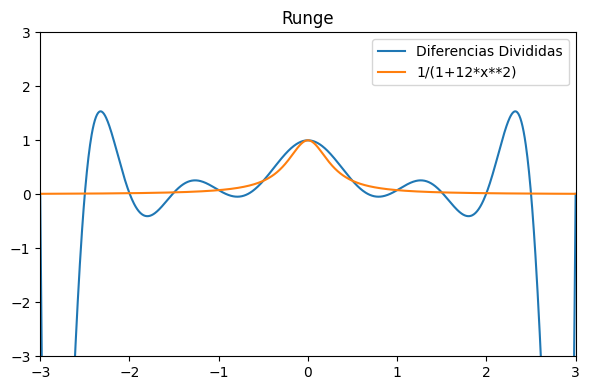

In [3]:
import numpy as np

x = np.linspace(-3,3,1000)

def f(x):
    return 1/(1+12*x**2)

px = np.linspace(-3,3,13)
py = f(px)

p = diferencias_divididas(x, px, py)

fig, ax = plt.subplots(figsize = (6,4))
ax.plot(x, p, label = "Diferencias Divididas")
ax.plot(x, f(x), label = '1/(1+12*x**2)')
ax.set_title('Runge')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.legend()
plt.tight_layout()
plt.show()

# Interpolación de Chebysev

La motivación de este tipo de interpolación es mejorar el control de valor máximo del error de interpolaicón.

$$f(x) - P(x) = \frac{(x - x_1)(x - x_2)...(x-x_n)}{n!}f^{(n)}(c)$$

Lo términos $(x-x_1)(x-x_2)...(x-x_n)$ es en mismo un polinomio de grado n en x y tiene un valor máximo en [-1,1]. ¿Es posible encontrar $x_1,..., x_n$ particulares en [-1,1] que permitan que el valor máximo en $(x-x_1)(x-x_2)...(x-x_n)$ sea lo más pequeño posible?

La selección de valores $-1 \le x_1,...,x_n \le 1$ que hace que el valor de:

$$\max_{-1 \le x \le 1} \lvert (x-x_1)...(x-x_n) \rvert$$

Sea lo más pequeño posible es:

$$x_i = cos(\frac{(2i-1)\pi}{2n})\,\,,i = 1,...,n$$

Y el valor mínimo es $\frac{1}{2^{n-1}}$. El mínimo es:

$$(x-x_1)(x-x_2)...(x-x_n) = \frac{1}{2^{n-1}}T_n(x) $$

Donde $T_n(x)$ es el polinomio de Chebyshev de grado n.

El error se minimiza al usar como nodos las raices del polinomio de Chebyshev de grado n. Osea:

$$x_i = cos(\frac{impar\,\, \pi}{2n})$$

A los polinomios de interpolación que usan las raices de Chebyshev se les llama polinomios de interpolación de Chebyshev.

Se define el polinomio enésimo de Chebysehv como $T_n(x) = cos(n arccos x). Para $n = 0$, $T_0(x) = 1$, para $n = 1$, $T_1(x) = cos(arccos(x)) = x$. Luego, para $n = 2$:

$$T_2(x) = cos(2arccosx)\,\,,y = arccosx$$

$$T_2(x) = cos(2y) = cos^2y-sin^2y = 2cos^y - 1 = 2x^2 - 1$$

Como:

$$T_{n+1}(x)=cos((n+1)y) = cos(ny+y)=cosnycosy-sinnysiny$$
$$T_{n-1}(x)=cos((n-1)y) = cos(ny-y)=cosnycosy+sinnysiny$$

$$T_{n+1}(x) + T_{n-1}(x) = 2cosnycosy = 2xT_n(x)$$

$$T_{n+1}(x) + T_{n-1}(x) = 2xT_n(x)$$

Para usar las raices en un intervalo fuera de $[-1,1]$, por ejemplo $[a,b]$ se mueven los puntos de manera que tengas las mismas posiciones relativas en el nuevo intervalo. Se necesita

1. Expandir los puntos por el factor $\frac{b-a}{2}$

2. Trasladar los puntos por $\frac{b+a}{2}$ para mover el centro de masa desde o hasta el punto medio de $[a,b]$.

En otras palabras, en el nuevo intervalo $[a,b]$:

$$x_i = \frac{b+a}{2} + \frac{b-a}{2}cos(\frac{(2i-1)\pi}{2n})\,\,,i = 1,..,n$$

$$\lvert (x-x_1)(x-x_2)...(x-x_n) \rvert = \frac{(\frac{b-a}{n})^2}{2^{n-1}}T_n(x) $$

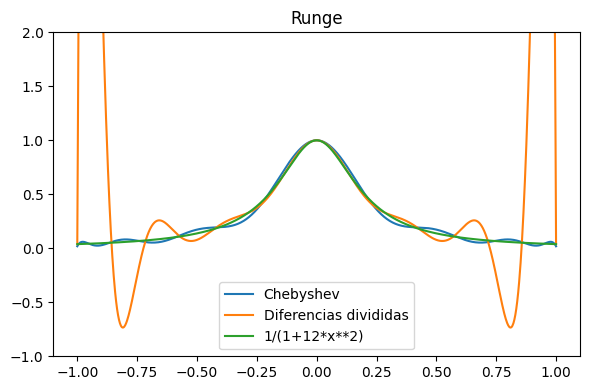

In [ ]:
# Polinomios de Chebyshev

import numpy as np

x = np.linspace(-1,1,1000)

def f(x):
    return 1/(1+25*x**2)

def nodos_chebyshev(n, a, b):
    indices = np.arange(1,n+1)
    return ((b+a)/2)+((b-a)/2)*np.cos((2*indices - 1)*np.pi/(2*indices.shape[0]))


px1 = nodos_chebyshev(15,-1,1)
px2 = np.linspace(-1,1,15)
py1 = f(px1)
py2 = f(px2)

p1 = diferencias_divididas(x, px1, py1)
p2 = diferencias_divididas(x, px2, py2)


fig, ax = plt.subplots(figsize = (6,4))
ax.plot(x, p1, label = "Chebyshev")
ax.plot(x, p2, label = "Diferencias divididas")
ax.plot(x, f(x), label = '1/(1+25*x**2)')
ax.set_title('Runge')
ax.set_ylim(-1,2)
ax.legend()
plt.tight_layout()
plt.show()
